# 02b — Modelo 2. Agrupación temática no supervisada de tweets


In [4]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

PROJECT_ROOT = Path('..').resolve()
DATA_INPUT = PROJECT_ROOT / 'data' / 'input'
DATA_PROCESSED = PROJECT_ROOT / 'data' / 'processed'
OUTPUTS_FIG = PROJECT_ROOT / 'outputs' / 'figures'
OUTPUTS_TABLES = PROJECT_ROOT / 'outputs' / 'tables'

for path in [DATA_INPUT, DATA_PROCESSED, OUTPUTS_FIG, OUTPUTS_TABLES]:
    path.mkdir(parents=True, exist_ok=True)

PREF_OUT = DATA_PROCESSED / 'tweets_clasificados_sentimiento.csv'
PREF_IN = DATA_INPUT / 'tweets_limpios_2020_2025_minecogob.csv'

if PREF_OUT.exists():
    fuente = PREF_OUT
    nota_fuente = 'datos ya clasificados por sentimiento en data/processed'
elif PREF_IN.exists():
    fuente = PREF_IN
    nota_fuente = 'datos crudos en data/input'
else:
    raise FileNotFoundError(
        f"No se encontró ninguno de los archivos esperados: {PREF_OUT} o {PREF_IN}. Asegúrate de que los datos estén en data/processed o data/input."
    )

print('Archivo de entrada:', fuente)
print('Origen:', nota_fuente)

tweets = pd.read_csv(fuente, encoding='utf-8-sig', low_memory=False)
print('Columnas disponibles:', list(tweets.columns))

Archivo de entrada: C:\Users\NADIA\TFG\src\analisis_del_dato\analisis_del_dato\data\processed\tweets_clasificados_sentimiento.csv
Origen: datos ya clasificados por sentimiento en data/processed
Columnas disponibles: ['id', 'fecha_dt', 'mes', 'username', 'contenido', 'texto_limpio', 'sentimiento_modelo', 'confianza_modelo', 'prob_pos', 'prob_neg', 'prob_neu', 'fecha', 'hashtags', 'tipo', 'url_media', 'comentarios', 'retweets', 'likes', 'views', 'fecha_limpia', 'texto_modelo']


## Carga robusta del corpus y construcción de la columna de texto

Se utiliza preferentemente `texto_limpio`, o `contenido` si no existe. Se eliminan textos nulos o vacíos para que el clustering trabaje con publicaciones efectivas.

Si existe una columna de fecha, se genera una columna `mes` para permitir la visualización temporal. Si no se puede construir `mes`, el clustering sigue funcionando y solo se omite la evolución mensual.

In [5]:
texto_col = 'texto_limpio' if 'texto_limpio' in tweets.columns else 'contenido' if 'contenido' in tweets.columns else None
if texto_col is None:
    raise ValueError('No se encontró ninguna columna de texto válida. Se requiere texto_limpio o contenido.')

tweets['texto_modelo'] = tweets[texto_col].astype(str).fillna('').str.strip()
tweets['texto_modelo'] = tweets['texto_modelo'].replace({'': np.nan})

fecha_col = None
for posible in ['fecha_dt', 'fecha', 'mes']:
    if posible in tweets.columns:
        posible_dt = pd.to_datetime(tweets[posible], errors='coerce')
        if posible_dt.notna().any():
            tweets['fecha_dt'] = posible_dt
            tweets['mes'] = posible_dt.dt.to_period('M').dt.to_timestamp()
            fecha_col = posible
            break

if 'mes' not in tweets.columns:
    tweets['mes'] = pd.NaT

tweets = tweets[tweets['texto_modelo'].notna()].copy()
print('Tweets con texto válido:', len(tweets))
print('Columna de texto usada:', texto_col)
print('Columna de fecha detectada:', fecha_col)
display(tweets.head(3))

Tweets con texto válido: 4590
Columna de texto usada: texto_limpio
Columna de fecha detectada: fecha_dt


,id,fecha_dt,mes,username,contenido,texto_limpio,sentimiento_modelo,confianza_modelo,prob_pos,prob_neg,...,fecha,hashtags,tipo,url_media,comentarios,retweets,likes,views,fecha_limpia,texto_modelo
0,2006087164900360491,2025-12-30 19:37:00,2025-12-01,@_minecogob,El ministro @carlos_cuerpo es entrevistado en ...,el ministro es entrevistado en el programa 'un...,neutro,0.768274,0.103679,0.128047,...,"Dec 30, 2025 · 7:37 PM UTC",NaN,Imagen,https://nitter.net/pic/orig/media%2FG9cNpJ6XAA...,0,1,3,528,"Dec 30, 2025 7:37 PM",el ministro es entrevistado en el programa 'un...
1,2005913464938614981,2025-12-30 08:06:00,2025-12-01,@_minecogob,"La inflación baja una décima en diciembre, al ...","la inflación baja una décima en diciembre, al ...",neutro,0.683655,0.099481,0.216864,...,"Dec 30, 2025 · 8:06 AM UTC",NaN,Imagen,https://nitter.net/pic/orig/media%2FG9ZvqkDXIA...,0,2,2,367,"Dec 30, 2025 8:06 AM","la inflación baja una décima en diciembre, al ..."
2,2003440348534833308,2025-12-23 12:19:00,2025-12-01,@_minecogob,"El @es_INE confirma que el PIB creció un 0,6% ...","el confirma que el pib creció un 0,6% en 3t, c...",neutro,0.586499,0.325938,0.087562,...,"Dec 23, 2025 · 12:19 PM UTC",NaN,Imagen,https://nitter.net/pic/orig/media%2FG82mYDZXAA...,0,3,2,1445,"Dec 23, 2025 12:19 PM","el confirma que el pib creció un 0,6% en 3t, c..."


## Vectorización TF-IDF

Se utiliza TF-IDF para transformar el texto en una representación numérica. El modelo no supervisado no utiliza etiquetas manuales ni información de sentimiento en esta etapa.

In [6]:
STOPWORDS_ES = [
    'el','la','los','las','un','una','unos','unas','de','del','al','y','o','en','por','para','con','sin','que','se','es','su','sus','como','más','pero','también','muy','ya','le','lo','le','qué','para','sobre','entre','esta','estas','este','estos','esta','ese','esa','estos','estas','ser','son','fue','ha','han','haber','desde','hasta','si','antes','después','durante','mientras','contra','hay','haber','era','fue','son','tan','lo','pues','este','esta','está','esto','otra','otro','otros','otras','muy','tal','tales','cada','mis','tus','sus','nuestro','nuestros','nuestra','nuestras','él','ella','ellos','ellas','nos','vos','mi','tu','aquellos','aquel','aquella','acá','allí','aquí',
    'ministerio','comercio','gobierno','minecogob','mineco','ministerial','ministerio','casa','nacional','nacionales','internacional','internacionales','estadísticas','producto','precio','precios','exportaciones','importaciones','institucional','institucionales','tweet','tweets','twitter','https','http','www','rt','amp'
]
vectorizer = TfidfVectorizer(
    max_features=3000,
    min_df=3,
    max_df=0.85,
    ngram_range=(1, 2),
    stop_words=STOPWORDS_ES,
)
X = vectorizer.fit_transform(tweets['texto_modelo'].astype(str))
print('Dimensiones TF-IDF:', X.shape)


Dimensiones TF-IDF: (4590, 3000)


## Selección de k con métricas no supervisadas

Se prueba KMeans para k de 3 a 8. La medida principal es silhouette score, porque se trata de un problema no supervisado. También se guarda la inercia para comparar la compacidad de los clusters.

In [7]:
metricas = []
for k in range(3, 9):
    modelo_k = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = modelo_k.fit_predict(X)
    inertia = float(modelo_k.inertia_)
    if X.shape[0] > k:
        sil = float(silhouette_score(X, etiquetas))
    else:
        sil = np.nan
    metricas.append({
        'k': k,
        'inertia': inertia,
        'silhouette': sil,
    })
metricas_df = pd.DataFrame(metricas)
metricas_df.to_csv(OUTPUTS_TABLES / 'metricas_clustering.csv', index=False, encoding='utf-8-sig')
display(metricas_df)

,k,inertia,silhouette
0,3,4421.050012,0.015086
1,4,4391.324490,0.015951
2,5,4363.365110,0.017668
3,6,4342.514906,0.016594
4,7,4320.935680,0.017273
5,8,4291.100413,0.020870


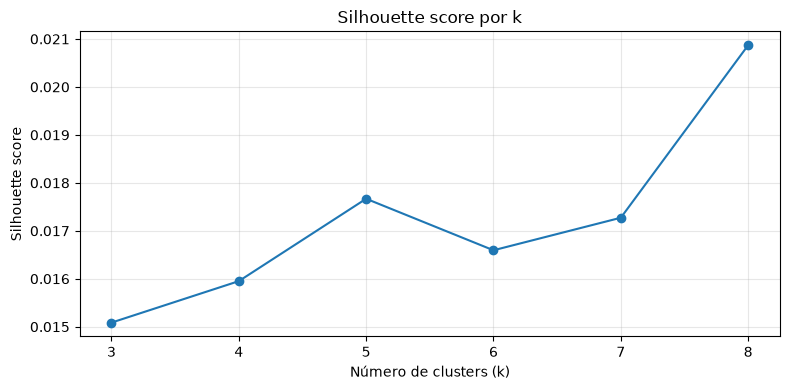

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(metricas_df['k'], metricas_df['silhouette'], marker='o')
ax.set_title('Silhouette score por k')
ax.set_xlabel('Número de clusters (k)')
ax.set_ylabel('Silhouette score')
ax.set_xticks(metricas_df['k'])
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(OUTPUTS_FIG / 'metricas_clustering_k.png', dpi=150)
plt.show()

## Entrenamiento final de KMeans

Se elige el mejor `k` según silhouette score por defecto, manteniéndolo editable para favorecer la interpretabilidad y la comparación manual.

In [9]:
K_FINAL = int(metricas_df.loc[metricas_df['silhouette'].idxmax(), 'k'])
print('K seleccionado por silhouette:', K_FINAL)

modelo_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
etiquetas_finales = modelo_final.fit_predict(X)
tweets['cluster_tema'] = etiquetas_finales

ruta_salida_cluster = DATA_PROCESSED / 'tweets_clasificados_sentimiento_clusters.csv'
tweets.to_csv(ruta_salida_cluster, index=False, encoding='utf-8-sig')
print('Archivo guardado:', ruta_salida_cluster)
print(tweets['cluster_tema'].value_counts().sort_index())

K seleccionado por silhouette: 8
Archivo guardado: C:\Users\NADIA\TFG\src\analisis_del_dato\analisis_del_dato\data\processed\tweets_clasificados_sentimiento_clusters.csv
cluster_tema
0     107
1     154
2     461
3     318
4     566
5     486
6      49
7    2449
Name: count, dtype: int64


## Términos principales por cluster

Se generan términos representativos de cada cluster y una interpretación prudente. Estas interpretaciones son propuestas iniciales y deben revisarse manualmente.

In [10]:
terminos = vectorizer.get_feature_names_out()
centros = modelo_final.cluster_centers_

def interpretar_terminos(top_terms):
    texto = ' '.join(top_terms).lower()
    if any(pal in texto for pal in ['export', 'exportaciones', 'aduana', 'logística', 'logistica']):
        return 'posible bloque temático de comercio exterior'
    if any(pal in texto for pal in ['import', 'importaciones', 'aduanas']):
        return 'posible bloque temático de importaciones'
    if any(pal in texto for pal in ['pyme', 'pymes', 'empresa', 'empresas', 'sector']):
        return 'posible bloque temático empresarial / pymes'
    if any(pal in texto for pal in ['covid', 'pandemia', 'salud']):
        return 'posible bloque temático de impacto sanitario'
    if any(pal in texto for pal in ['acuerdo', 'tratado', 'mercado', 'internacional', 'union', 'ue', 'euro']):
        return 'posible bloque temático de acuerdos o mercado'
    return 'revisar manualmente'

filas = []
for cluster_idx, centro in enumerate(centros):
    mejores = centro.argsort()[-8:][::-1]
    top = [terminos[i] for i in mejores]
    filas.append({
        'cluster_tema': int(cluster_idx),
        'n_tweets': int((tweets['cluster_tema'] == cluster_idx).sum()),
        'porcentaje': round((tweets['cluster_tema'] == cluster_idx).mean() * 100, 2),
        'terminos_principales': ', '.join(top),
        'interpretacion_propuesta': interpretar_terminos(top),
    })
clusters_terminos = pd.DataFrame(filas)
clusters_terminos.to_csv(OUTPUTS_TABLES / 'clusters_terminos_principales.csv', index=False, encoding='utf-8-sig')
display(clusters_terminos)

,cluster_tema,n_tweets,porcentaje,terminos_principales,interpretacion_propuesta
0,0,107,2.33,"operaciones, financiación, empresas, líneadeav...",posible bloque temático empresarial / pymes
1,1,154,3.36,"the, to, of, and, we, in, is, for",revisar manualmente
2,2,461,10.04,"vicepresidenta, horas, endirecto, directo, par...",posible bloque temático de acuerdos o mercado
3,3,318,6.93,"piped video, piped, video, directo, partir, mi...",revisar manualmente
4,4,566,12.33,"crecimiento, inflación, economía, empleo, espa...",posible bloque temático de acuerdos o mercado
5,5,486,10.59,"bit, bit ly, ly, planderecuperación, vicepresi...",posible bloque temático de acuerdos o mercado
6,6,49,1.07,"generación, únete generación, planderecuperaci...",posible bloque temático de acuerdos o mercado
7,7,2449,53.36,"vp, planderecuperación, españa, empresas, econ...",posible bloque temático empresarial / pymes


## Ejemplos representativos por cluster

Se seleccionan los tweets más cercanos al centroide de cada cluster para facilitar la revisión cualitativa.

In [11]:
distancias = modelo_final.transform(X)
dist_cluster = distancias[np.arange(len(etiquetas_finales)), etiquetas_finales]
tweets['distancia_centroide'] = dist_cluster
candidatos = tweets.sort_values(['cluster_tema', 'distancia_centroide']).groupby('cluster_tema', group_keys=False).head(5)
columnas_ejemplo = ['cluster_tema', 'distancia_centroide']
for fecha_cand in ['fecha_dt', 'fecha']:
    if fecha_cand in candidatos.columns:
        columnas_ejemplo.append(fecha_cand)
        break
if 'mes' in candidatos.columns:
    columnas_ejemplo.append('mes')
if 'texto_limpio' in candidatos.columns:
    columnas_ejemplo.append('texto_limpio')
elif 'texto_modelo' in candidatos.columns:
    columnas_ejemplo.append('texto_modelo')
for col in ['sentimiento_modelo', 'sentimiento', 'confianza_modelo', 'confianza']:
    if col in candidatos.columns:
        columnas_ejemplo.append(col)
candidatos = candidatos.loc[:, columnas_ejemplo] 
ruta_ejemplos = OUTPUTS_TABLES / 'ejemplos_clusters_tweets.csv'
candidatos.to_csv(ruta_ejemplos, index=False, encoding='utf-8-sig')
print('Archivo guardado:', ruta_ejemplos)
display(candidatos.head(10))

Archivo guardado: C:\Users\NADIA\TFG\src\analisis_del_dato\analisis_del_dato\outputs\tables\ejemplos_clusters_tweets.csv


,cluster_tema,distancia_centroide,fecha_dt,mes,texto_limpio,sentimiento_modelo,confianza_modelo
3945,0,0.768067,2020-12-11 12:17:00,2020-12-01,la líneadeavales de puesta en marcha para gara...,neutro,0.710120
3966,0,0.768067,2020-12-04 11:15:00,2020-12-01,la líneadeavales de puesta en marcha para gara...,neutro,0.716555
4042,0,0.768688,2020-11-07 10:05:00,2020-11-01,la líneadeavales de puesta en marcha para gara...,neutro,0.705895
3859,0,0.770588,2021-01-22 13:29:00,2021-01-01,la líneadeavales de puesta en marcha para gara...,neutro,0.699812
4000,0,0.772297,2020-11-21 11:07:00,2020-11-01,la líneadeavales de puesta en marcha para gara...,neutro,0.703485
1728,1,0.699580,2022-11-24 11:57:00,2022-11-01,➡️vp financialstabilityeu: we have anticipated...,neutro,0.721068
939,1,0.722732,2023-10-17 07:19:00,2023-10-01,the ecofin will formally approve the second ph...,positivo,0.631711
2554,1,0.727836,2022-03-17 15:45:00,2022-03-01,➡️vp cohesionforum: we are all on the same boa...,neutro,0.619960
930,1,0.728595,2023-10-18 18:54:00,2023-10-01,spain is in a leading position as we approach ...,neutro,0.642375
2441,1,0.732501,2022-04-21 16:57:00,2022-04-01,➡️vp : we have been able to deliver a response...,neutro,0.491267


## Visualizaciones del clustering

Se guardan gráficas que ayudan a interpretar la calidad y la distribución de los clusters. Estas visualizaciones complementan el análisis de sentimiento con una perspectiva temática no supervisada.

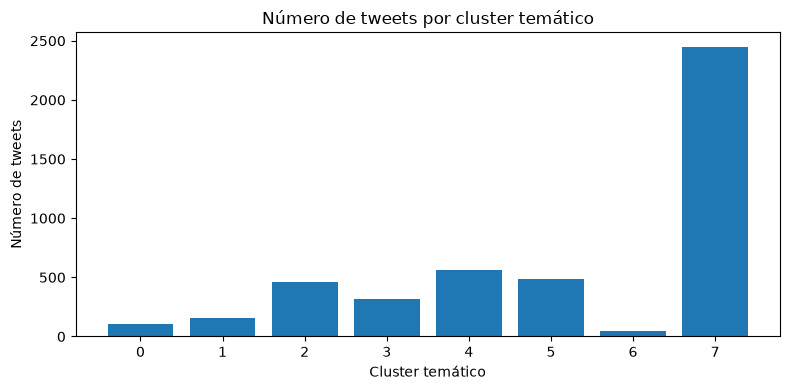

In [12]:
cuenta_cluster = tweets['cluster_tema'].value_counts().sort_index().reset_index()
cuenta_cluster.columns = ['cluster_tema', 'n_tweets']
cuenta_cluster['porcentaje'] = (cuenta_cluster['n_tweets'] / cuenta_cluster['n_tweets'].sum() * 100).round(2)
cuenta_cluster.to_csv(OUTPUTS_TABLES / 'distribucion_clusters_tweets.csv', index=False, encoding='utf-8-sig')

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(cuenta_cluster['cluster_tema'].astype(str), cuenta_cluster['n_tweets'], color='tab:blue')
ax.set_title('Número de tweets por cluster temático')
ax.set_xlabel('Cluster temático')
ax.set_ylabel('Número de tweets')
plt.tight_layout()
fig.savefig(OUTPUTS_FIG / 'distribucion_clusters_tweets.png', dpi=150)
plt.show()

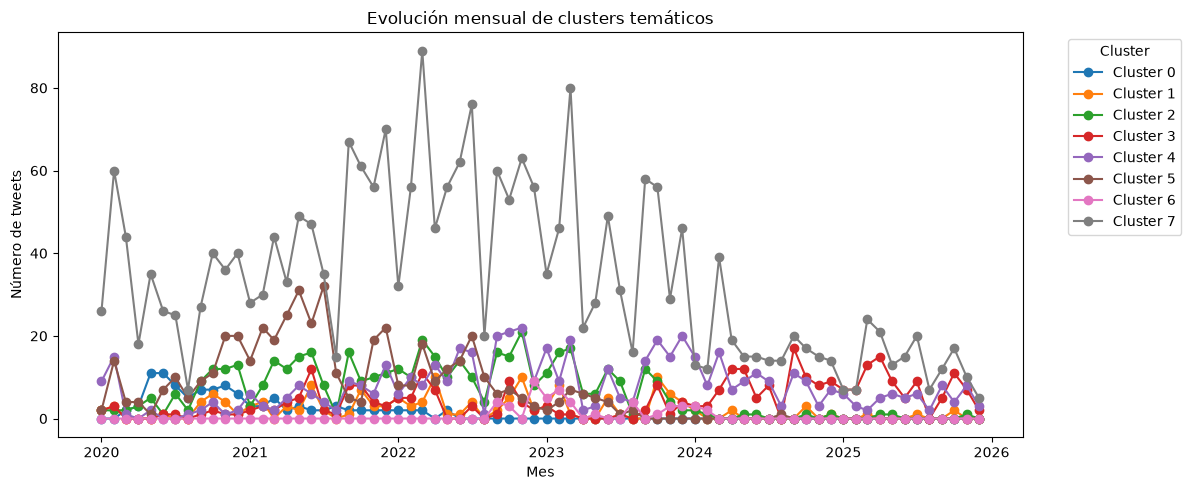

In [13]:
if tweets['mes'].notna().any():
    evolucion = (
        tweets.groupby(['mes', 'cluster_tema'])['cluster_tema']
        .count()
        .unstack(fill_value=0)
        .sort_index()
    )
    evolucion.to_csv(OUTPUTS_TABLES / 'evolucion_clusters_mensual.csv', encoding='utf-8-sig')
    fig, ax = plt.subplots(figsize=(12, 5))
    for cluster in evolucion.columns:
        ax.plot(evolucion.index, evolucion[cluster], marker='o', label=f'Cluster {cluster}')
    ax.set_title('Evolución mensual de clusters temáticos')
    ax.set_xlabel('Mes')
    ax.set_ylabel('Número de tweets')
    ax.legend(title='Cluster', bbox_to_anchor=(1.04, 1), loc='upper left')
    plt.tight_layout()
    fig.savefig(OUTPUTS_FIG / 'evolucion_clusters_mensual.png', dpi=150)
    plt.show()
else:
    print('No hay columna mes válida para generar la evolución mensual de clusters.')

In [14]:
tabla_resumen = pd.DataFrame([
    {
        'modelo': 'pysentimiento',
        'tipo': 'supervisado preentrenado',
        'objetivo': 'clasificar sentimiento de tweets',
        'metricas_adecuadas': 'cobertura, confianza media, distribución de clases, revisión cualitativa, coherencia temporal',
        'visualizaciones': 'distribución de sentimiento, evolución mensual, ITIm-ICC',
        'interpretacion': 'permite construir el ITIm mensual, no predecir el ICC',
    },
    {
        'modelo': 'TF-IDF + KMeans',
        'tipo': 'no supervisado',
        'objetivo': 'agrupar tweets por similitud textual',
        'metricas_adecuadas': 'silhouette, inertia, tamaño de clusters, términos principales, ejemplos representativos',
        'visualizaciones': 'silhouette por k, distribución de clusters, evolución mensual de clusters',
        'interpretacion': 'permite identificar bloques temáticos recurrentes, no validar causalidad ni predicción',
    },
])
tabla_resumen.to_csv(OUTPUTS_TABLES / 'tabla_resumen_metricas_modelos.csv', index=False, encoding='utf-8-sig')
display(tabla_resumen)

,modelo,tipo,objetivo,metricas_adecuadas,visualizaciones,interpretacion
0,pysentimiento,supervisado preentrenado,clasificar sentimiento de tweets,"cobertura, confianza media, distribución de cl...","distribución de sentimiento, evolución mensual...","permite construir el ITIm mensual, no predecir..."
1,TF-IDF + KMeans,no supervisado,agrupar tweets por similitud textual,"silhouette, inertia, tamaño de clusters, térmi...","silhouette por k, distribución de clusters, ev...",permite identificar bloques temáticos recurren...
